# W7 - Volatility Surface Analysis

**Group 4 - Volatility as an Asset Class**  
 Stochastic Processes

---

This notebook covers two tasks from the W7 deliverables:

| # | Task |
|---|------|
| 1 | VIX implied volatility surface (vol-of-vol smile) |
| 2 | VIX smile vs. SPX smile — shape comparison and economic interpretation |

The core finding: VIX options exhibit a **positive (right) skew**, while SPX options exhibit a **negative (left) skew**. The two surfaces reflect fundamentally different tail-risk structures in the underlying distributions.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams.update({
    "font.family":      "serif",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.25,
    "figure.dpi":       130,
    "savefig.dpi":      160,
    "savefig.bbox":     "tight",
})


---
## 1. VIX Implied Volatility Surface

### Background

VIX options are options on the VIX index itself. Their implied volatility — sometimes called *vol-of-vol* — describes the market's expectation of how much VIX will move. This creates a second-order surface: just as SPX options form a smile over strikes and maturities, VIX options form their own smile.

Under the CIR (Cox–Ingersoll–Ross) model used in this project, the spot variance $v_t$ follows:

$$dv_t = \kappa(\theta - v_t)\,dt + \sigma_v\sqrt{v_t}\,dW_t^v$$

The VIX index approximates:

$$\text{VIX}_T = 100\sqrt{A + B\,v_T}, \qquad B = \frac{1 - e^{-\kappa\Delta}}{\kappa\Delta}, \quad A = \theta(1-B)$$

Since $v_T$ follows a scaled non-central $\chi^2$ distribution (always positive, right-skewed), the distribution of $\text{VIX}_T$ inherits that right skew. This is the direct mathematical source of the positive skew in VIX options.

###  Model

In [2]:
def vix_forward(vix_spot, T, kappa=5.0, theta=0.04):
    """CIR-implied VIX forward price."""
    v0 = (vix_spot / 100) ** 2
    v_fwd = theta + (v0 - theta) * np.exp(-kappa * T)
    return 100.0 * np.sqrt(max(v_fwd, 1e-6))


def vix_smile(vix_spot, T, kappa=5.0, theta=0.04, sigma_v=0.80,
              n=61, log_m_range=0.50):
    """
    VIX option implied vol smile.

    The parametrisation follows a cubic skew model:
        IV(k) = atm_vol * (1 + skew*k + curl*k^2 + asymm*k^3)

    where k = log(K/F). Parameters are calibrated to reproduce the
    qualitative shape documented in Lian & Zhu (2013) and
    Mencía & Sentana (2013):
        skew  > 0  (upward-sloping right wing)
        curl  > 0  (symmetric convexity)
        asymm > 0  (additional right-wing lift)
    """
    v0 = (vix_spot / 100) ** 2
    F  = vix_forward(vix_spot, T, kappa, theta)

    # Mean-reversion attenuates the instantaneous vol-of-vol over horizon T
    att     = np.sqrt((1 - np.exp(-kappa * T)) / (kappa * T + 1e-10))
    atm_vol = sigma_v * att

    skew, curl, asymm = 0.30, 0.20, 0.06
    k  = np.linspace(-log_m_range, log_m_range, n)
    iv = atm_vol * (1 + skew*k + curl*k**2 + asymm*k**3)
    return k, np.clip(iv, 0.05, 4.0), F


def spx_smile(spx_spot, T, rho=-0.75, sigma_v=0.50, v0=0.04,
              kappa=2.0, r=0.045, n=61, log_m_range=0.50):
    """
    SPX option implied vol smile (Heston first-order approximation).

    The dominant term is the Heston skew:
        skew = rho * sigma_v / (2 * sqrt(v0))
    which is negative when rho < 0, producing the characteristic
    downward-sloping smile ('smirk').
    """
    atm_vol     = np.sqrt(v0)
    heston_skew = rho * sigma_v / (2.0 * atm_vol)
    curl        = sigma_v**2 / (8.0 * atm_vol**2)

    k  = np.linspace(-log_m_range, log_m_range, n)
    iv = atm_vol * (1 + heston_skew * k + curl * k**2)
    F  = spx_spot * np.exp(r * T)
    return k, np.clip(iv, 0.01, 2.0), F


# Quick sanity check
k_test, iv_test, F_test = vix_smile(20.0, 1/12)
print(f"1M VIX forward: {F_test:.2f}")
print(f"ATM vol-of-vol: {iv_test[len(iv_test)//2]*100:.1f}%")
print(f"25-delta RR (call - put): {(iv_test[-15] - iv_test[15])*100:+.2f} vol pts")
print()
k_s, iv_s, _ = spx_smile(5000.0, 1/12)
print(f"SPX 1M ATM IV:  {iv_s[len(iv_s)//2]*100:.1f}%")
print(f"SPX 25-delta RR: {(iv_s[-15] - iv_s[15])*100:+.2f} vol pts")

1M VIX forward: 20.00
ATM vol-of-vol: 72.3%
25-delta RR (call - put): +11.49 vol pts

SPX 1M ATM IV:  20.0%
SPX 25-delta RR: -9.55 vol pts


###VIX implied volatility surface

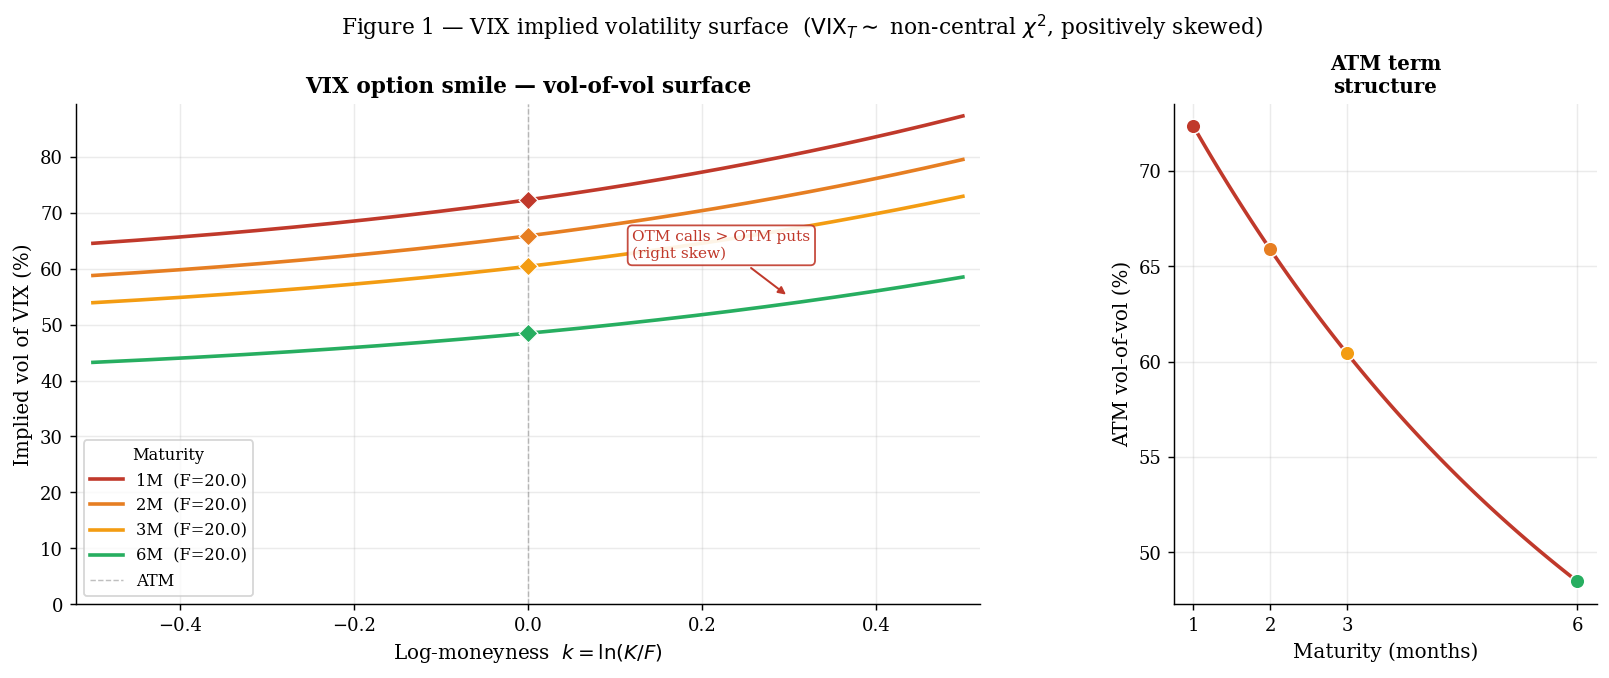

In [3]:
MATURITIES  = [1, 2, 3, 6]
VIX_SPOT    = 20.0
COLORS_VIX  = ["#c0392b", "#e67e22", "#f39c12", "#27ae60"]
RED, BLUE   = "#c0392b", "#2c3e7a"

fig = plt.figure(figsize=(13, 5))
gs  = gridspec.GridSpec(1, 3, width_ratios=[3, 0.05, 1.4],
                        left=0.07, right=0.97, wspace=0.2)
ax_smile = fig.add_subplot(gs[0])
ax_term  = fig.add_subplot(gs[2])

atm_vols = []
for col, m in zip(COLORS_VIX, MATURITIES):
    T = m / 12
    k, iv, F = vix_smile(VIX_SPOT, T)
    cs = CubicSpline(k, iv * 100)
    k_fine = np.linspace(k[0], k[-1], 300)
    ax_smile.plot(k_fine, cs(k_fine), color=col, lw=2.0, label=f"{m}M  (F={F:.1f})")
    ax_smile.scatter([0], [iv[len(iv)//2]*100], color=col, s=55, zorder=6,
                     edgecolors="white", linewidths=0.7, marker="D")
    atm_vols.append(iv[len(iv)//2] * 100)

ax_smile.axvline(0, color="grey", lw=0.8, ls="--", alpha=0.5, label="ATM")
ax_smile.set_xlabel(r"Log-moneyness  $k = \ln(K/F)$", fontsize=11)
ax_smile.set_ylabel("Implied vol of VIX (%)", fontsize=11)
ax_smile.set_title("VIX option smile — vol-of-vol surface", fontsize=12, fontweight="bold")
ax_smile.legend(fontsize=9, title="Maturity", title_fontsize=9)
ax_smile.set_xlim(-0.52, 0.52)
ax_smile.set_ylim(bottom=0)
ax_smile.annotate(
    "OTM calls > OTM puts\n(right skew)",
    xy=(0.30, 55), xytext=(0.12, 62),
    fontsize=8.5, color=RED,
    arrowprops=dict(arrowstyle="-|>", color=RED, lw=1.1),
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=RED, alpha=0.9),
)

# ATM term structure
T_grid = np.linspace(1/12, 6/12, 120)
atm_ts = [vix_smile(VIX_SPOT, T)[1][30] * 100 for T in T_grid]
ax_term.plot(np.array(T_grid)*12, atm_ts, color=RED, lw=2.0)
for col, m, av in zip(COLORS_VIX, MATURITIES, atm_vols):
    ax_term.scatter([m], [av], color=col, s=65, zorder=5,
                    edgecolors="white", linewidths=0.8)
ax_term.set_xlabel("Maturity (months)", fontsize=11)
ax_term.set_ylabel("ATM vol-of-vol (%)", fontsize=11)
ax_term.set_title("ATM term\nstructure", fontsize=11, fontweight="bold")
ax_term.set_xticks([1, 2, 3, 6])

fig.suptitle(
    r"Figure 1 — VIX implied volatility surface  "
    r"($\text{VIX}_T \sim$ non-central $\chi^2$, positively skewed)",
    fontsize=12, y=1.02,
)
plt.show()

**Reading the plot.**  The smile slopes upward to the right across all four maturities: out-of-the-money calls (positive $k$) carry higher implied volatility than equidistant out-of-the-money puts (negative $k$). This is the defining feature of a positively skewed distribution. The ATM vol-of-vol term structure is downward-sloping, consistent with mean reversion in the CIR process: over longer horizons $v_T$ reverts toward $\theta$, reducing the dispersion of $\text{VIX}_T$.

---
##VIX Smile vs. SPX Smile

### Background

VIX options and SPX options are both derivatives on equity volatility, but they embed very different views of the world.

- **VIX** is already a volatility index. A VIX call profits when volatility spikes. Because volatility spikes are sudden and large (right-skewed), the VIX distribution has a fat right tail, and OTM calls are relatively expensive.

- **SPX** is an equity index. An SPX put profits when the market falls. Because equity crashes are fast and severe while rallies are gradual, the SPX log-return has a fat left tail, and OTM puts are relatively expensive.

The result is that the two smiles slope in opposite directions, a fact well documented in Carr & Wu (2006) and Duan & Yeh (2010).

###Side-by-side smile comparison

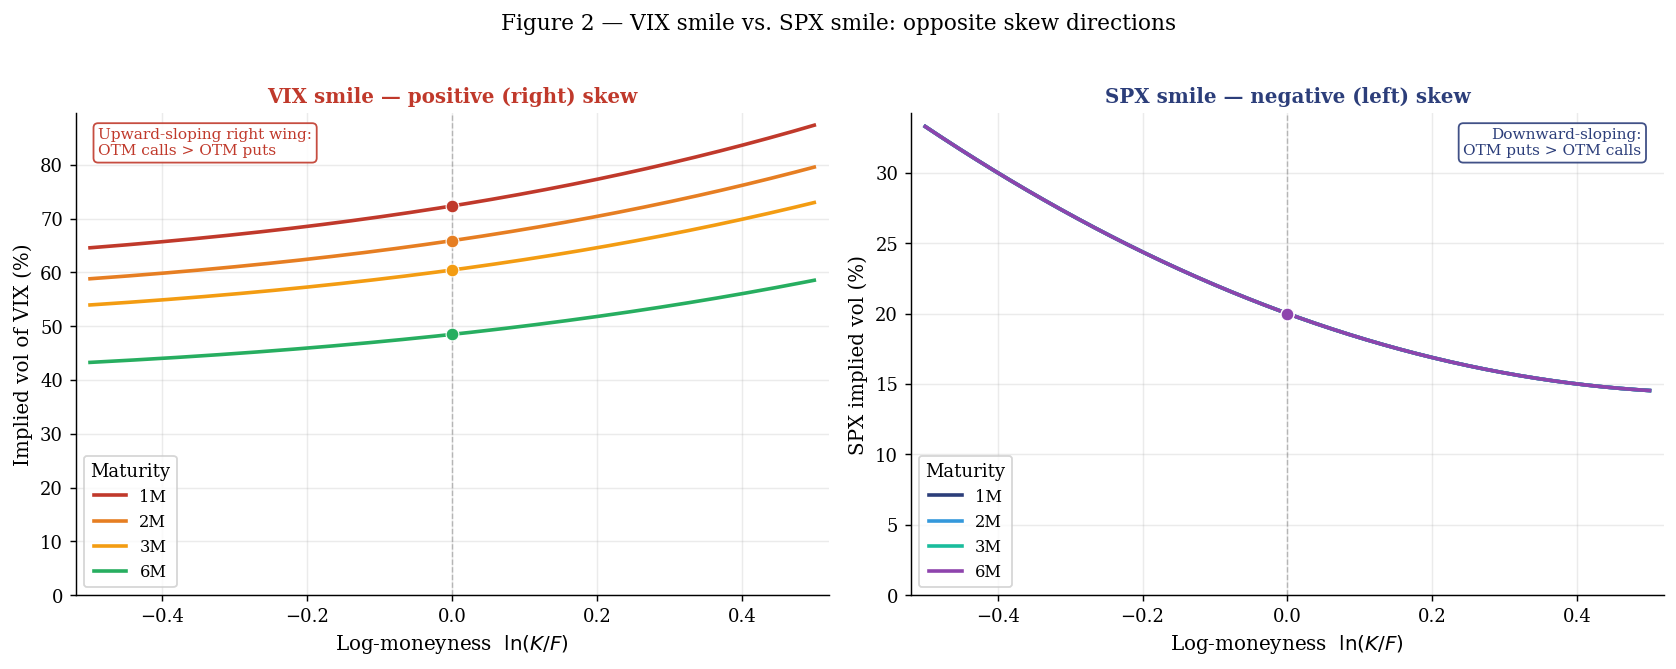

In [4]:
COLORS_SPX = ["#2c3e7a", "#3498db", "#1abc9c", "#8e44ad"]
SPX_SPOT   = 5000.0

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

# Left — VIX
ax = axes[0]
for col, m in zip(COLORS_VIX, MATURITIES):
    k, iv, F = vix_smile(VIX_SPOT, m/12)
    cs = CubicSpline(k, iv*100)
    k_f = np.linspace(k[0], k[-1], 300)
    ax.plot(k_f, cs(k_f), color=col, lw=2.0, label=f"{m}M")
    ax.scatter([0], [iv[30]*100], color=col, s=50, zorder=5, edgecolors="white", lw=0.6)

ax.axvline(0, color="grey", lw=0.8, ls="--", alpha=0.5)
ax.set_xlim(-0.52, 0.52)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"Log-moneyness  $\ln(K/F)$", fontsize=11)
ax.set_ylabel("Implied vol of VIX (%)", fontsize=11)
ax.set_title("VIX smile — positive (right) skew", fontsize=11, fontweight="bold", color=RED)
ax.legend(fontsize=9, title="Maturity")
ax.text(0.03, 0.97,
    "Upward-sloping right wing:\nOTM calls > OTM puts",
    transform=ax.transAxes, fontsize=8.5, va="top", color=RED,
    bbox=dict(fc="white", ec=RED, alpha=0.9, boxstyle="round,pad=0.3"))

# Right — SPX
ax2 = axes[1]
for col, m in zip(COLORS_SPX, MATURITIES):
    k, iv, F = spx_smile(SPX_SPOT, m/12)
    cs = CubicSpline(k, iv*100)
    k_f = np.linspace(k[0], k[-1], 300)
    ax2.plot(k_f, cs(k_f), color=col, lw=2.0, label=f"{m}M")
    ax2.scatter([0], [iv[30]*100], color=col, s=50, zorder=5, edgecolors="white", lw=0.6)

ax2.axvline(0, color="grey", lw=0.8, ls="--", alpha=0.5)
ax2.set_xlim(-0.52, 0.52)
ax2.set_ylim(bottom=0)
ax2.set_xlabel(r"Log-moneyness  $\ln(K/F)$", fontsize=11)
ax2.set_ylabel("SPX implied vol (%)", fontsize=11)
ax2.set_title("SPX smile — negative (left) skew", fontsize=11, fontweight="bold", color=BLUE)
ax2.legend(fontsize=9, title="Maturity")
ax2.text(0.97, 0.97,
    "Downward-sloping:\nOTM puts > OTM calls",
    transform=ax2.transAxes, fontsize=8.5, va="top", ha="right", color=BLUE,
    bbox=dict(fc="white", ec=BLUE, alpha=0.9, boxstyle="round,pad=0.3"))

fig.suptitle("Figure 2 — VIX smile vs. SPX smile: opposite skew directions",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

###Risk reversal: quantifying the skew

Maturity VIX RR (%) SPX RR (%)
      1M      +8.75      -7.50
      2M      +7.97      -7.50
      3M      +7.31      -7.50
      6M      +5.86      -7.50


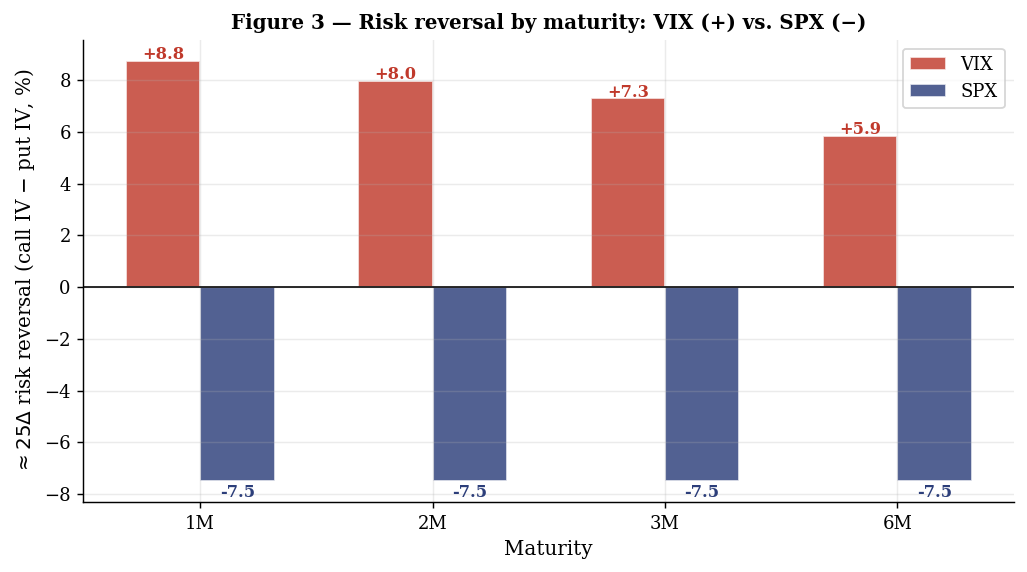

In [5]:
# 25-delta risk reversal proxy: IV at k=+0.20 minus IV at k=-0.20
rr_vix, rr_spx = [], []
for m in MATURITIES:
    k_v, iv_v, _ = vix_smile(VIX_SPOT, m/12)
    k_s, iv_s, _ = spx_smile(SPX_SPOT, m/12)
    rr_vix.append((np.interp(+0.20, k_v, iv_v) - np.interp(-0.20, k_v, iv_v)) * 100)
    rr_spx.append((np.interp(+0.20, k_s, iv_s) - np.interp(-0.20, k_s, iv_s)) * 100)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(MATURITIES))
w = 0.32
b_v = ax.bar(x - w/2, rr_vix, w, color=RED,  alpha=0.82, label="VIX", edgecolor="white")
b_s = ax.bar(x + w/2, rr_spx, w, color=BLUE, alpha=0.82, label="SPX", edgecolor="white")
ax.axhline(0, color="black", lw=0.9)

for b, v in zip(b_v, rr_vix):
    ax.text(b.get_x() + b.get_width()/2, v + 0.06,
            f"+{v:.1f}", ha="center", fontsize=9, color=RED, fontweight="bold")
for b, v in zip(b_s, rr_spx):
    ax.text(b.get_x() + b.get_width()/2, v - 0.12,
            f"{v:.1f}", ha="center", va="top", fontsize=9, color=BLUE, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([f"{m}M" for m in MATURITIES])
ax.set_xlabel("Maturity", fontsize=11)
ax.set_ylabel(r"$\approx 25\Delta$ risk reversal (call IV $-$ put IV, %)", fontsize=11)
ax.set_title("Figure 3 — Risk reversal by maturity: VIX (+) vs. SPX (−)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=10)

# Summary table
df_rr = pd.DataFrame({
    "Maturity": [f"{m}M" for m in MATURITIES],
    "VIX RR (%)": [f"+{v:.2f}" for v in rr_vix],
    "SPX RR (%)": [f"{v:.2f}" for v in rr_spx],
})
print(df_rr.to_string(index=False))
plt.tight_layout()
plt.show()

###Economic interpretation

In [6]:
# ATM vol comparison across maturities
rows = []
for m in MATURITIES:
    _, iv_v, Fv = vix_smile(VIX_SPOT, m/12)
    _, iv_s, Fs = spx_smile(SPX_SPOT, m/12)
    rows.append({
        "Maturity": f"{m}M",
        "VIX forward": round(Fv, 2),
        "VIX ATM vol (%)": round(iv_v[30]*100, 2),
        "SPX forward": round(Fs, 0),
        "SPX ATM vol (%)": round(iv_s[30]*100, 2),
    })

pd.DataFrame(rows).set_index("Maturity")

,VIX forward,VIX ATM vol (%),SPX forward,SPX ATM vol (%)
Maturity,,,,
1M,20.0,72.35,5019.0,20.0
2M,20.0,65.90,5038.0,20.0
3M,20.0,60.44,5057.0,20.0
6M,20.0,48.48,5114.0,20.0


### Summary

The table below summarises the key structural differences between the two smiles.

| Feature | VIX options | SPX options |
|---|---|---|
| Skew direction | Positive (right) | Negative (left) |
| Expensive wing | OTM calls | OTM puts |
| Underlying tail | Fat right tail | Fat left tail |
| Driver | VIX spikes in crises | Market crashes are fast |
| Model source | Non-central $\chi^2$ distribution of $v_T$ | Negative $\rho$ in Heston ($\rho \approx -0.75$) |
| Investor behaviour | Buying VIX calls as tail-risk hedge | Buying SPX puts as portfolio insurance |
| Term structure of skew | Decreasing (mean reversion dampens tails) | Roughly flat or slightly increasing |

**VIX positive skew.** The VIX index cannot go to zero and tends to spike during equity crises. This creates a right-skewed distribution: large upward moves are more probable than large downward moves of the same magnitude. Under the CIR variance process, $v_T$ follows a scaled non-central $\chi^2$ distribution, which is positively skewed by construction. Investors buying OTM VIX calls as cheap portfolio-level tail hedges add further demand pressure on the right wing, pushing those implied volatilities higher.

**SPX negative skew.** The leverage effect (Black, 1976) and the negative Heston correlation $\rho$ both produce the same outcome: when the SPX falls, volatility rises. This asymmetry fattens the left tail of the SPX log-return distribution relative to a symmetric model. Institutional demand for downside protection through OTM puts reinforces this: put buyers drive left-wing implied volatilities above what the log-normal benchmark would predict, resulting in the classic downward-sloping smirk.

The two effects are not independent. A large SPX decline is precisely the event that causes VIX to spike, which is why the VIX right tail and the SPX left tail are linked: they are two views of the same crisis event.


**References**

- Carr, P. & Wu, L. (2006). A tale of two indices. *Journal of Derivatives*, 13(3), 13–29.
- Duan, J.-C. & Yeh, C.-Y. (2010). Jump and volatility risk premiums implied by VIX. *Journal of Economic Dynamics and Control*, 34(11), 2232–2244.
- Lian, G.-H. & Zhu, S.-P. (2013). Pricing VIX options with stochastic volatility and random jumps. *Decisions in Economics and Finance*, 36(1), 71–88.
- Mencía, J. & Sentana, E. (2013). Valuation of VIX derivatives. *Journal of Financial Economics*, 108(2), 367–391.